Tugas Train Dataset Gambar 

 Anggota <br>
 Dio Ferdi Jaya (2308107010018)<br>
 Randy Maulana (2308107010054)

link Dataset : https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification/code

Deskripsi Dataset : <br>

Dataset Daun Kacang (Bean Leaf Dataset) adalah sekumpulan data gambar yang dirancang khusus untuk melatih model machine learning atau Computer Vision dalam mendeteksi penyakit pada tanaman kacang secara otomatis. Terdiri dari sekitar 1.295 gambar yang terbagi secara merata ke dalam tiga kelas—daun sehat (Healthy), penyakit bercak daun bersudut (Angular Leaf Spot), dan penyakit karat daun (Bean Rust)—dataset ini menawarkan studi kasus agrikultur di dunia nyata yang sangat relevan untuk teknologi pertanian modern. Dengan ukurannya yang relatif ringan (±170 MB) dan fokus objek yang jelas pada area daun, dataset ini sangat ideal untuk eksperimen klasifikasi multikelas yang efisien, memungkinkan proses training model berjalan dengan cepat namun tetap menghasilkan akurasi yang dapat diandalkan tanpa membebani sumber daya komputasi.

# Import Libraries

In [11]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import sys
print(sys.executable)
import tensorflow as tf
print(tf.__version__)
# Core Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix

d:\Software\Python\python.exe
2.20.0


Seluruh library yang dibutuhkan untuk preprocessing, visualisasi, model, dan evaluasi dimuat.
Kode juga menampilkan interpreter Python yang digunakan (`sys.executable`) dan versi TensorFlow (`tf.__version__`), sehingga kita tahu environment yang dipakai.

# Environment Configuration

In [12]:
def seed_everything(seed=42):
    # Fix seed untuk Python, Numpy, dan TensorFlow
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Memaksa TensorFlow berjalan konsisten
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

seed_everything(42)

# Cek apakah GPU tersedia (sama seperti kode PyTorch-mu tadi)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('Device: CPU (GPU tidak ditemukan, proses training mungkin agak lambat)')
else:
    print(f'Device: GPU ditemukan di {device_name}')

Device: CPU (GPU tidak ditemukan, proses training mungkin agak lambat)


Fungsi `seed_everything()` menetapkan seed untuk Python, NumPy, dan TensorFlow agar hasil lebih deterministik.
Kemudian memeriksa apakah GPU tersedia. output menyatakan tidak ada gpu dan hanya menggunakan cpu, training akan berjalan di CPU dan prosesnya bisa menjadi lebih lambat.

# Data Loading & Preprocessing

In [13]:
# Tentukan lokasi folder dataset
# Pastikan folder 'dataset' berada di satu folder yang sama dengan file .ipynb ini
train_path = 'train'
val_path = 'val'

# 1. Konfigurasi Preprocessing & Augmentasi untuk Data Training
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalisasi piksel
    rotation_range=20,         # Putar gambar maksimal 20 derajat
    width_shift_range=0.2,     # Geser lebar
    height_shift_range=0.2,    # Geser tinggi
    shear_range=0.2,           # Memiringkan gambar
    zoom_range=0.2,            # Perbesar sedikit
    horizontal_flip=True,      # Balik kanan-kiri
    fill_mode='nearest'        # Isi piksel kosong hasil manipulasi
)

# 2. Konfigurasi Preprocessing untuk Data Validasi (Hanya Rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# 3. Mengalirkan gambar dari folder secara otomatis
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),    # Resize semua gambar jadi 150x150
    batch_size=32,             # Sekali angkut 32 gambar
    class_mode='categorical'   # Karena klasifikasi 3 kelas
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False

)

Found 1034 images belonging to 3 classes.
Found 133 images belonging to 3 classes.


Data training dimuat dari folder `train` dengan augmentasi:
- rotasi,
- geser,
- shear,
- zoom,
- flip horizontal.

Data validasi hanya dinormalisasi (`rescale=1./255`) tanpa augmentasi.
Generator ini otomatis membaca label dan mengubah gambar menjadi ukuran `150x150`.

# Exploratory Data Analysis (Visualizing Samples)

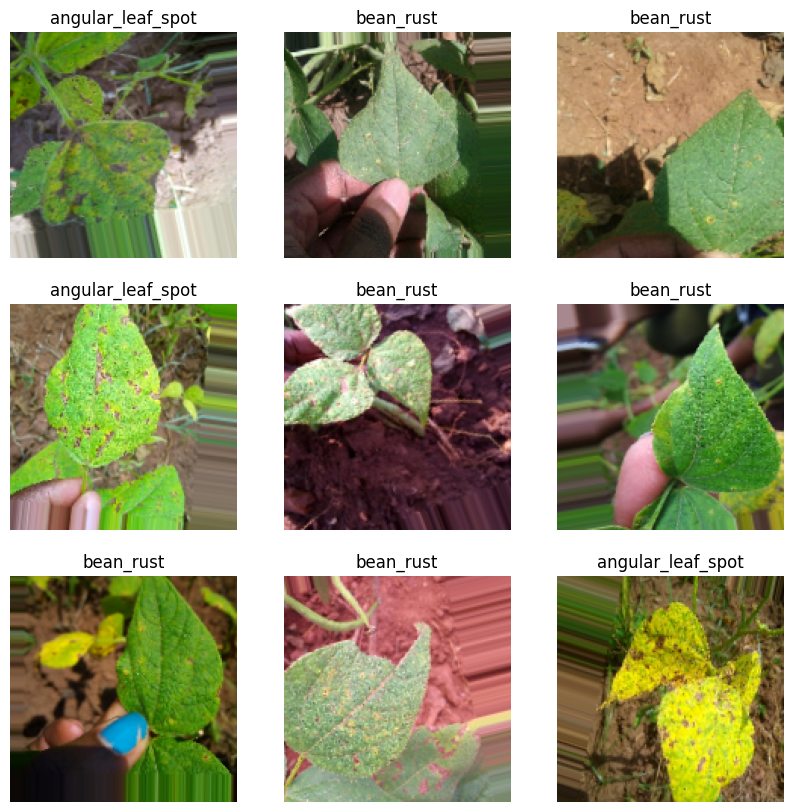

In [14]:
# Mengambil satu batch data (32 gambar)
images, labels = next(train_generator)

# Mendapatkan nama kelas
class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Menampilkan gambar
    plt.imshow(images[i])
    # Menampilkan label aslinya
    title = class_names[np.argmax(labels[i])]
    plt.title(title)
    plt.axis('off')

plt.show()

Menampilkan 9 contoh gambar dari batch training.
Tujuannya untuk memastikan gambar, normalisasi, dan label sudah benar.

Jika gambar terlihat kabur, terbalik, atau label tidak sesuai, itu tanda perlu perbaikan preprocessing atau struktur folder.

# Membangun Arsitektur Model CNN

In [15]:
# Membangun arsitektur Sequential
model = models.Sequential([
    # Layer 1: Mendeteksi fitur dasar (garis, warna)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Layer 2: Mendeteksi fitur yang lebih kompleks (tekstur bercak)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Layer 3: Mendeteksi pola penyakit secara spesifik
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Flatten: Mengubah matriks 2D menjadi vektor 1D
    layers.Flatten(),
    
    # Dense Layer (Otak pengambil keputusan)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),      # Mencegah model "menghafal" (overfitting)
    layers.Dense(3, activation='softmax') # Output 3 kelas
])

# Menampilkan ringkasan arsitektur model
model.summary()

d:\Software\Python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Model CNN terdiri dari:
- beberapa convolutional layer untuk ekstraksi fitur,
- pooling untuk mereduksi dimensi,
- flatten untuk mengubah output menjadi vektor,
- dense layer untuk klasifikasi,
- dropout untuk mengurangi overfitting,
- output softmax dengan 3 kelas.

`model.summary()` menampilkan jumlah parameter dan arsitektur keseluruhan.

# Training Model

In [16]:
# 1. Compile Model (Menentukan aturan belajar)
model.compile(
    optimizer='adam',               # Optimizer otomatis yang sangat stabil
    loss='categorical_crossentropy', # Karena klasifikasi lebih dari 2 kelas
    metrics=['accuracy']            # Kita pantau akurasinya
)

# 2. Proses Training
# Simpan ke dalam variabel 'history' supaya kita bisa bikin grafik nantinya
print("Memulai training... Silakan tunggu, ini mungkin memakan waktu beberapa menit.")

history = model.fit(
    train_generator,
    epochs=20,                      # 20 putaran belajar
    validation_data=val_generator,  # Uji coba langsung dengan data validasi
    verbose=1                       # Menampilkan progres bar
)

Memulai training... Silakan tunggu, ini mungkin memakan waktu beberapa menit.
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 576ms/step - accuracy: 0.4304 - loss: 1.0665 - val_accuracy: 0.4211 - val_loss: 1.0298
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 534ms/step - accuracy: 0.5735 - loss: 0.9184 - val_accuracy: 0.7143 - val_loss: 0.6839
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step - accuracy: 0.6518 - loss: 0.8284 - val_accuracy: 0.6767 - val_loss: 0.6585
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 538ms/step - accuracy: 0.6654 - loss: 0.7673 - val_accuracy: 0.6692 - val_loss: 0.6971
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 532ms/step - accuracy: 0.6867 - loss: 0.7279 - val_accuracy: 0.7368 - val_loss: 0.5872
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 544ms/step - accuracy: 0.6905 - loss: 0.7340 - val_accuracy: 0.7368 - val_loss: 0.6243
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 593ms/step - accuracy: 0.6770 - loss: 0.7548 - val_accuracy: 0.7293 - val_loss: 0.6222
Epoch 8/20
33/33 ━━

Model dikompilasi dengan `adam`, `categorical_crossentropy`, dan metrik `accuracy`.
Training dilakukan selama 20 epoch menggunakan data training dan validasi.

Hasil training disimpan di `history` untuk analisis grafik akurasi dan loss.

# Visualisasi Performa Model

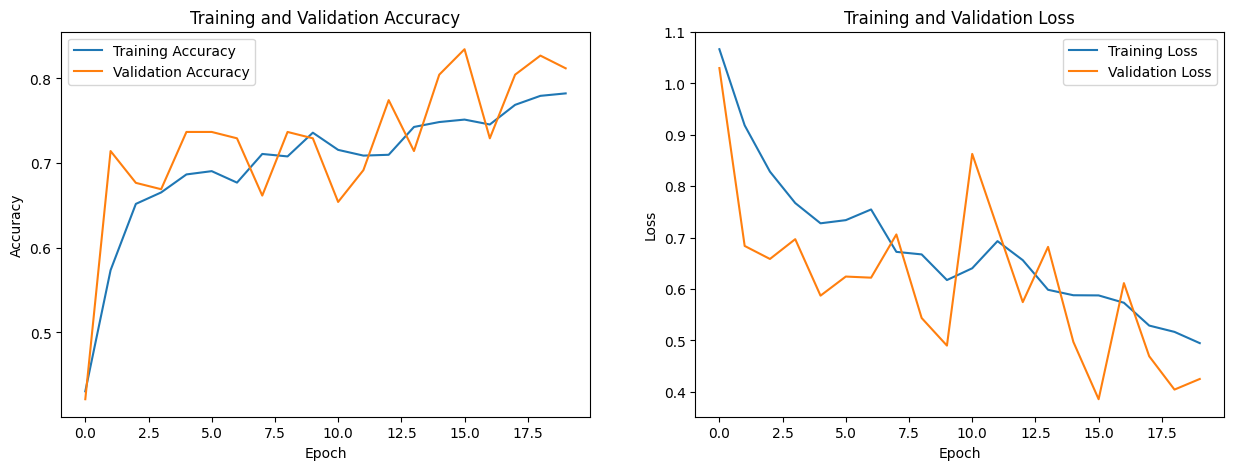

In [17]:
# Membuat figure dengan 2 subplot
plt.figure(figsize=(15, 5))

# Subplot 1: Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Grafik ini menampilkan:
- `Training Accuracy` vs `Validation Accuracy`
- `Training Loss` vs `Validation Loss`

Jika kurva training jauh lebih baik dari validasi, itu tanda overfitting.
Jika kedua kurva tidak naik/turun dengan stabil, itu tanda model belum cukup fit atau hyperparameter perlu penyesuaian.

# Laporan Klasifikasi & Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step
Classification Report:
                   precision    recall  f1-score   support

angular_leaf_spot       0.76      0.84      0.80        44
        bean_rust       0.88      0.64      0.74        45
          healthy       0.82      0.95      0.88        44

         accuracy                           0.81       133
        macro avg       0.82      0.81      0.81       133
     weighted avg       0.82      0.81      0.81       133



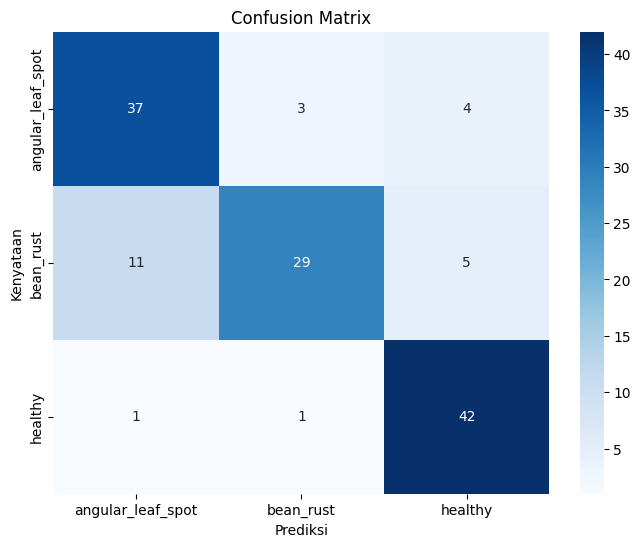

In [18]:
# 1. Ambil label asli dan prediksi
val_generator.reset() # Reset generator agar urutannya pas
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# 2. Print Classification Report
target_names = list(val_generator.class_indices.keys())
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 3. Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan')
plt.title('Confusion Matrix')
plt.show()

Di sini model diuji terhadap seluruh data validasi:
- `classification_report` menunjukkan precision, recall, f1-score untuk setiap kelas,
- `confusion_matrix` menunjukkan keakuratan prediksi tiap kelas secara visual.

Confusion matrix membantu menemukan kelas mana yang sering tertukar.

In [22]:
# Test dengan gambar baru
image_path_test = 'val/healthy/healthy_train.1.jpg'
def predict_leaf(image_path_test):
    import numpy as np
    from tensorflow.keras.preprocessing import image
    
    # 1. Load & Preprocess gambar
    img = image.load_img(image_path_test, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.
    
    # 2. Prediksi
    prediction = model.predict(img_array)
    classes = list(train_generator.class_indices.keys())
    result = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    
    print(f"Hasil Prediksi: {result} ({confidence:.2f}%)")

# Contoh cara pakai (Ganti dengan path gambar kamu):
predict_leaf('train/healthy/healthy_train.1.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Hasil Prediksi: healthy (95.38%)


Fungsi `predict_leaf()` memuat satu gambar baru, memprosesnya, lalu memprediksi kelas.
Hasilnya menampilkan:
- `Hasil Prediksi`,
- `Confidence` dalam persentase.

Ini digunakan untuk memastikan model dapat digunakan pada gambar tunggal di luar batch generator.

# save model

In [ ]:
# Menentukan nama file
model_name = 'model_penyakit_daun_kacang.h5'

# Perintah untuk menyimpan
model.save(model_name)

print(f"Model berhasil disimpan sebagai: {model_name}")

Model berhasil disimpan sebagai: model_penyakit_daun_kacang.h5


: 